In [1]:
import kagglehub
import pandas as pd
import hashlib
import json

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")



print("Path to dataset files:", path)
import os

# 1. Join the directory path with the specific CSV filename
csv_file_path = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 2. Read the CSV file
df = pd.read_csv(csv_file_path)

Path to dataset files: /home/yaponsk/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1


In [2]:
import numpy as np

# index=False -- row *position* carries no content meaning, so it shouldn't affect
# the hash either. XOR-combine the per-row hashes instead of hashing them in
# whatever order the rows happen to arrive in -- XOR is order-independent, so a
# re-shuffled-but-identical CSV (e.g. Kaggle re-exports it in a new row order)
# now produces the SAME hash instead of a false 'drift' warning.
row_hashes = pd.util.hash_pandas_object(df, index=False).values.astype(np.uint64)
df_hash = hashlib.sha256(np.bitwise_xor.reduce(row_hashes).tobytes()).hexdigest()
print(f"Dataset hash: {df_hash}")

if os.path.exists('dataset_baseline.json'):
    with open('dataset_baseline.json') as f:
        baseline_hash = json.load(f)['dataset_hash']
    if df_hash != baseline_hash:
        print(f"⚠️ WARNING: dataset hash changed!\nBaseline: {baseline_hash}\nCurrent:  {df_hash}")
    else:
        print("Dataset hash matches baseline — no drift detected.")
else:
    with open('dataset_baseline.json', 'w') as f:
        json.dump({'dataset_hash': df_hash}, f, indent=2)
    print(f"Baseline dataset hash recorded: {df_hash}")

Dataset hash: e509e674fc08e00ab0cc0b9bdc61fb26128e65c24d272ab9f68a7271c59f043e
Dataset hash matches baseline — no drift detected.


In [3]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve,
    average_precision_score
)

from sklearn.model_selection import RandomizedSearchCV

import matplotlib.pyplot as plt
import seaborn as sns
from campaign_profit import (best_threshold, break_even_threshold,
                             campaign_profit, profit_curve)

import warnings

# Show each DISTINCT warning once, rather than suppressing everything.
#
# This was a bare filterwarnings('ignore'), which silenced every warning for
# the whole session -- during the one activity where you most want to hear
# about problems. Lifting it revealed ~1,457 warnings from the model-
# comparison cell alone, including: LogisticRegression's `penalty` argument
# is deprecated in scikit-learn 1.8 and REMOVED IN 1.10, so that cell's
# penalty: ['l1','l2'] search will break on upgrade. It was also hiding any
# ConvergenceWarning from that same Logistic Regression -- checked, there
# are none, so its reported ROC-AUC is sound.
#
# 'once' keeps output readable inside a 200-iteration search while leaving
# every distinct problem visible. If a specific warning is investigated and
# accepted, suppress that one by category -- don't restore the catch-all.
warnings.simplefilter('once')

# Set plotting style
sns.set_theme(style="whitegrid")

In [4]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_")
df = df.replace(["?", "", "NA", "nan",' '], np.nan)
df = df.drop('customerid', axis=1)
df.columns

Index(['gender', 'seniorcitizen', 'partner', 'dependents', 'tenure',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod',
       'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   seniorcitizen     7043 non-null   int64  
 2   partner           7043 non-null   str    
 3   dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   phoneservice      7043 non-null   str    
 6   multiplelines     7043 non-null   str    
 7   internetservice   7043 non-null   str    
 8   onlinesecurity    7043 non-null   str    
 9   onlinebackup      7043 non-null   str    
 10  deviceprotection  7043 non-null   str    
 11  techsupport       7043 non-null   str    
 12  streamingtv       7043 non-null   str    
 13  streamingmovies   7043 non-null   str    
 14  contract          7043 non-null   str    
 15  paperlessbilling  7043 non-null   str    
 16  paymentmethod     7043 non-null   str    
 17  monthl

In [6]:
df.describe(include='all')

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
count,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7032,7043
unique,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6530,2
top,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [7]:
df.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
dupes = df[df.duplicated(keep=False)]
dupes.sort_values(list(df.columns)).head(20)

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
6491,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.2,Yes
6764,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.2,Yes
4495,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.1,Yes
6267,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.1,Yes
5522,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
5759,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
542,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1491,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
5170,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No
6774,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No


In [9]:
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows ({len(df)} remaining)")

Dropped 22 duplicate rows (7021 remaining)


In [10]:
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')


In [11]:
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})

In [12]:
from feature_engineering_telco import engineer_features

y = df['churn']
X = df.drop(columns=['churn'], inplace=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# engineer_features is applied per-split (not once on the full df) even though
# it's currently stateless — keeps the pattern correct if a future feature
# ever needs .fit() on training data only (e.g. target encoding).
# Keep the raw test frame before engineering. The sample CSV written at the
# end of the notebook is drawn from this, not from the engineered X_test:
# telco_model.py's contract is the 19 raw columns a real export would have,
# and shipping a 25-column pre-engineered file misrepresents it. The batch
# script tolerates either (engineer_features is idempotent), which is
# exactly why the wrong one went unnoticed.
X_test_raw = X_test.copy()

X_train = engineer_features(X_train)
X_test  = engineer_features(X_test)
X_tr    = engineer_features(X_tr) #---------#
X_val   = engineer_features(X_val)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [13]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category','string']).columns.tolist()


def make_preprocessor():
    """Build a FRESH preprocessor. Call this per pipeline; don't share one.

    Pipeline.fit() fits its steps in place rather than cloning them, so a
    single ColumnTransformer handed to several pipelines is one mutable
    object with several owners: fitting any of them silently re-fits the
    scaler and encoder the others are holding. Nothing is wrong today --
    RandomizedSearchCV and cross_val_score clone internally, and every
    pipeline here is refit before it is used -- but the day one pipeline is
    fit on one slice and a different one is asked to predict without a
    refit, the answer comes from the wrong scaler and nothing raises.

    StandardScaler is a no-op for the tree models; it is here for the
    Logistic Regression in the model-comparison cell.
    """
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    return ColumnTransformer([
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ])

***visualualization of the baseline models. next 6 cells can be removed later for cosmetic effect and saving computationion time***

In [14]:
model_pipeline = Pipeline([
    ('preprocessor', make_preprocessor()),
    ('classifier', XGBClassifier(random_state=42))
])

In [15]:
model_pipeline.fit(X_tr, y_tr) 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['gender','seniorcitizen','partner',...,'contractvstenure', 'average_monthly_charges','charge_change_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By sp

        MODEL EVALUATION METRICS          

ROC-AUC Score: 0.8356

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       827
           1       0.62      0.52      0.57       297

    accuracy                           0.79      1124
   macro avg       0.73      0.70      0.71      1124
weighted avg       0.78      0.79      0.78      1124



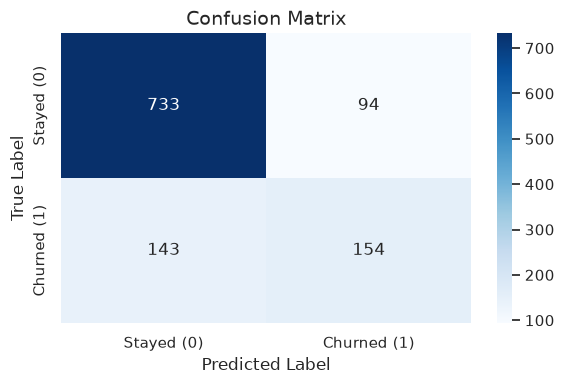

In [16]:
# 1. Generate predictions and probabilities from the test set
y_pred = model_pipeline.predict(X_val)
y_pred_proba = model_pipeline.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_pred_proba)
class_report = classification_report(y_val, y_pred)
conf_matrix = confusion_matrix(y_val, y_pred)

# 3. Print the text reports
print("==========================================")
print("        MODEL EVALUATION METRICS          ")
print("==========================================\n")
print(f"ROC-AUC Score: {roc_auc:.4f}\n")
print("Classification Report:")
print(class_report)

# 4. Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed (0)', 'Churned (1)'], 
            yticklabels=['Stayed (0)', 'Churned (1)'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
neg_cases = y_tr.value_counts()[0]
pos_cases = y_tr.value_counts()[1]
spw = neg_cases / pos_cases
print(f"Negative Cases: {neg_cases}")
print(f"Positive Cases: {pos_cases}")
print(f"Scale Positives Weight: {spw}")

Negative Cases: 3304
Positive Cases: 1188
Scale Positives Weight: 2.781144781144781


        MODEL EVALUATION METRICS          

ROC-AUC Score: 0.8381

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       827
           1       0.58      0.63      0.60       297

    accuracy                           0.78      1124
   macro avg       0.72      0.73      0.72      1124
weighted avg       0.79      0.78      0.78      1124



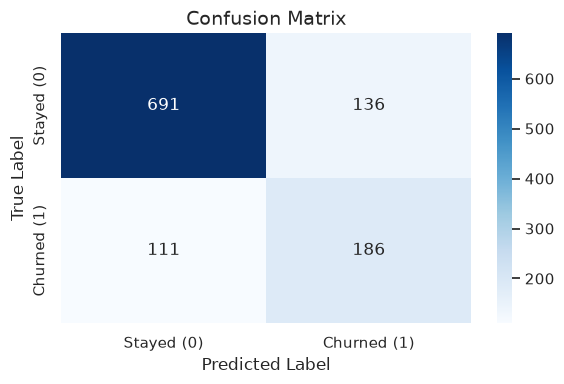

In [18]:
#compare the model with and without spw
model_pipeline_tuned = Pipeline([
    ('preprocessor', make_preprocessor()),
    ('classifier', XGBClassifier(random_state=42, scale_pos_weight=spw))
])
model_pipeline_tuned.fit(X_tr, y_tr)
# 1. Generate predictions and probabilities from the test set
y_pred = model_pipeline_tuned.predict(X_val)
y_pred_proba = model_pipeline_tuned.predict_proba(X_val)[:, 1]

# 2. Calculate core metrics
roc_auc = roc_auc_score(y_val, y_pred_proba)
class_report = classification_report(y_val, y_pred)
conf_matrix = confusion_matrix(y_val, y_pred)

# 3. Print the text reports
print("==========================================")
print("        MODEL EVALUATION METRICS          ")
print("==========================================\n")
print(f"ROC-AUC Score: {roc_auc:.4f}\n")
print("Classification Report:")
print(class_report)

# 4. Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed (0)', 'Churned (1)'], 
            yticklabels=['Stayed (0)', 'Churned (1)'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

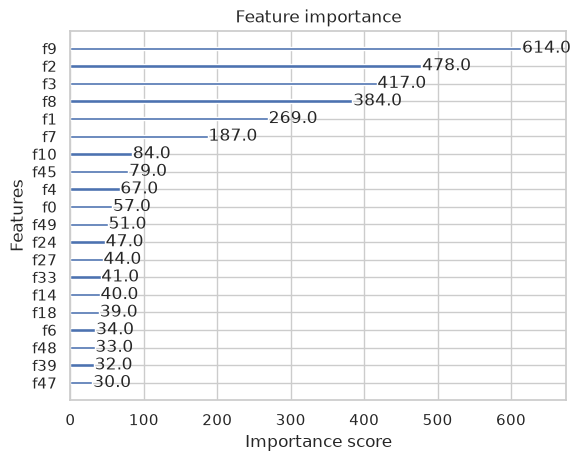

In [19]:
xgb.plot_importance(model_pipeline_tuned.named_steps['classifier'], importance_type='weight', max_num_features=20)
plt.show()
#deal with feature names later, for now just get the feature importance and plot it.

In [20]:
cv_scores = cross_val_score(
    estimator=model_pipeline_tuned,   # full pipeline (preprocessor + XGBoost)
    X=X_train,
    y=y_train,
    cv=cv_strategy,             
    scoring='roc_auc',          # Highly recommended for imbalanced churn data
    n_jobs=-1                 # -1 everywhere else; 3 here was a leftover
)

# 3. Print the results beautifully
print("--- Cross-Validation Results ---")
print(f"Scores per fold: {cv_scores}")
print(f"Mean ROC-AUC:    {cv_scores.mean():.4f}")
print(f"Standard Dev:    {cv_scores.std():.4f}")
print(f"95% Conf. Range: [{cv_scores.mean() - (2 * cv_scores.std()):.4f} to {cv_scores.mean() + (2 * cv_scores.std()):.4f}]")

--- Cross-Validation Results ---
Scores per fold: [0.8495149  0.80227212 0.80654609 0.8401937  0.80054581]
Mean ROC-AUC:    0.8198
Standard Dev:    0.0207
95% Conf. Range: [0.7783 to 0.8613]


***end of visualizng the baseline***

In [21]:
#hyperparameter tuning 
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
param_distributions = {
    'classifier__n_estimators': randint(50, 150),
    'classifier__max_depth': randint(3, 6),
    'classifier__learning_rate': uniform(0.01, 0.2),
    'classifier__subsample': uniform(0.6, 0.4),
    'classifier__colsample_bytree': uniform(0.6, 0.4),
    'classifier__min_child_weight': randint(1, 10),
    'classifier__scale_pos_weight': uniform(1.0, spw * 2)
}
# 2. Set up the Randomized Search
random_search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_distributions,
    n_iter=200,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_tr, y_tr)

# 3. Fit the search on your training data
print("Starting hyperparameter tuning...")

# 4. Extract and print the best results
print("\n--- Tuning Results ---")
print(f"Best ROC-AUC Score on CV: {random_search.best_score_:.4f}")
print("Best Hyperparameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Starting hyperparameter tuning...

--- Tuning Results ---
Best ROC-AUC Score on CV: 0.8458
Best Hyperparameters found:
  classifier__colsample_bytree: 0.6606699518931004
  classifier__learning_rate: 0.07234441355910964
  classifier__max_depth: 3
  classifier__min_child_weight: 7
  classifier__n_estimators: 82
  classifier__scale_pos_weight: 1.1865171117289817
  classifier__subsample: 0.8279558739485267


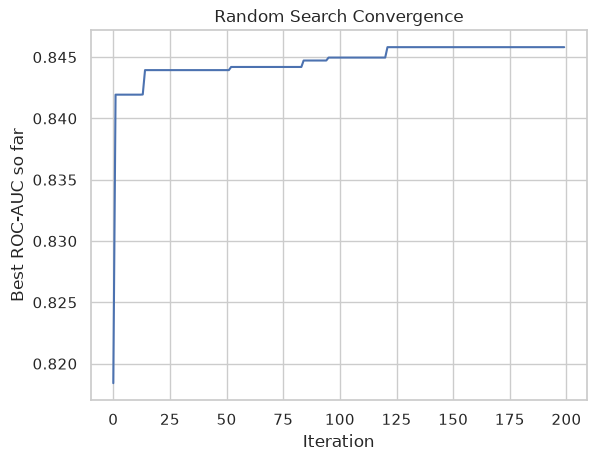

In [22]:
import matplotlib.pyplot as plt

scores = random_search.cv_results_['mean_test_score']
running_best = pd.Series(scores).cummax()

plt.plot(running_best)
plt.xlabel('Iteration')
plt.ylabel('Best ROC-AUC so far')
plt.title('Random Search Convergence')
plt.show()

In [23]:
# # 1. Predict using the best model found during the search
# y_pred = random_search.predict(X_test)
# y_proba = random_search.predict_proba(X_test)[:, 1]

# # 2. Print the final performance report
# print("--- Final Tuned Model Test Performance ---")
# print(classification_report(y_test, y_pred))
# print(f"Tuned Test ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

In [24]:
# 1. Extract the tuned and trained pipeline from the search. basically renamed it to best_tuned_model for clarity
best_tuned_model = random_search.best_estimator_

# 2. Evaluate using Stratified K-Fold Cross Validation on the BEST model
cv_roc_auc = cross_val_score(best_tuned_model, X_train, y_train, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
cv_f1 = cross_val_score(best_tuned_model, X_train, y_train, cv=cv_strategy, scoring='f1', n_jobs=-1)

# PR-AUC (average precision) reported alongside ROC-AUC because the classes
# are imbalanced (~26% churn). ROC-AUC counts true negatives, and with 74% of
# rows negative it stays comfortable even when the churner ranking degrades.
# PR-AUC ignores true negatives entirely, so it tracks performance on the
# class the campaign actually spends money on. Its floor is the positive rate,
# NOT 0.5 -- a model that ranks at random scores ~0.26 here, so that is the
# number to compare against, printed below.
cv_pr_auc = cross_val_score(best_tuned_model, X_train, y_train, cv=cv_strategy,
                            scoring='average_precision', n_jobs=-1)

print(f"Stratified 5-Fold CV ROC-AUC: {cv_roc_auc.mean():.4f} (+/- {cv_roc_auc.std():.4f})")
print(f"Stratified 5-Fold CV PR-AUC:  {cv_pr_auc.mean():.4f} (+/- {cv_pr_auc.std():.4f})"
      f"   [random baseline = {y_train.mean():.4f}]")
print(f"Stratified 5-Fold CV F1-Score: {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")

# 3. Generate predictions using the best model
y_pred_balanced = best_tuned_model.predict(X_val)
print("\nClassification Report (Balanced):")
print(classification_report(y_val, y_pred_balanced))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_balanced))

Stratified 5-Fold CV ROC-AUC: 0.8491 (+/- 0.0175)
Stratified 5-Fold CV PR-AUC:  0.6643 (+/- 0.0374)   [random baseline = 0.2644]
Stratified 5-Fold CV F1-Score: 0.6103 (+/- 0.0213)

Classification Report (Balanced):
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       827
           1       0.68      0.61      0.64       297

    accuracy                           0.82      1124
   macro avg       0.77      0.75      0.76      1124
weighted avg       0.82      0.82      0.82      1124


Confusion Matrix:
[[743  84]
 [117 180]]


In [25]:
# 1. Get UNBIASED (out-of-fold) probability predictions on X_train (X_tr + X_val,
#    80% of the data), via 5-fold CV. Each row's prediction comes from a fold that
#    never trained on it, so these are safe to use for threshold selection even
#    though X_train is also what the FINAL model gets refit on below -- unlike
#    reusing X_val after a refit, there's no leakage here.
best_tuned_model = random_search.best_estimator_
oof_proba = cross_val_predict(
    best_tuned_model, X_train, y_train,
    cv=cv_strategy, method='predict_proba', n_jobs=-1
)[:, 1]

# 2. Coarse threshold scan -- on (y_train, oof_proba)
thresholds = np.arange(0.0, 1.0, 0.05)
threshold_results = []

for thresh in thresholds:  #--------#
    y_pred_thresh = (oof_proba >= thresh).astype(int)
    precision = precision_score(y_train, y_pred_thresh, pos_label=1, zero_division=0)
    recall = recall_score(y_train, y_pred_thresh, pos_label=1)
    f1 = f1_score(y_train, y_pred_thresh, pos_label=1)
    false_positives = ((y_pred_thresh == 1) & (y_train == 0)).sum()
    false_negatives = ((y_pred_thresh == 0) & (y_train == 1)).sum()
    threshold_results.append({
        'Threshold': thresh, 'Precision (Confidence)': round(precision, 3),
        'Recall (Catch Rate)': round(recall, 3), 'F1-Score': round(f1, 3),
        'False Alarms (FP)': false_positives, 'Missed Churners (FN)': false_negatives
    })

df_thresholds = pd.DataFrame(threshold_results)






# --- Business assumptions behind the profit formula ---
# These three constants convert a probability threshold into a dollar figure.
# They're illustrative assumptions for this project, not numbers pulled from
# real finance/marketing data -- flagging that explicitly rather than letting
# them look empirically derived.

# CLV: estimated $ value of successfully retaining this customer. Rough
# proxy = avg monthly charge * expected extra months of retention a
# successful save buys (e.g. ~$70/mo * ~3 months ~= $200).
clv = 200

# Cost applied to every customer TARGETED by the campaign, whether or not
# the retention offer works (e.g. a discount/incentive, or agent outreach
# time) -- not just the successes.
cost = 20

# Fraction of TARGETED churners actually retained by the campaign (not
# 100% -- some churn anyway despite the outreach). Treated here as a
# placeholder assumption; replace with real historical campaign conversion
# data if this were deployed.
success_rate = 0.3

#--------#


total_actual_churners = y_train.sum()
df_thresholds['True Positives (TP)'] = total_actual_churners - df_thresholds['Missed Churners (FN)']
df_thresholds['Campaign Profit ($)'] = campaign_profit(
    df_thresholds['True Positives (TP)'], df_thresholds['False Alarms (FP)'],
    clv=clv, cost=cost, success_rate=success_rate
)#----------------#

# Full coarse-grid table: precision/recall/F1 alongside FP/FN/TP/profit for every threshold checked
coarse_table = df_thresholds.sort_values(by='Campaign Profit ($)', ascending=False).reset_index(drop=True)
print("=== Coarse-Grid Threshold Scan (5-fold OOF predictions on X_train) ===")
print(coarse_table.to_string(index=False))

best_coarse_threshold = coarse_table.iloc[0]['Threshold']
print(f"\nCoarse-grid best threshold (5-fold OOF on X_train): {best_coarse_threshold:.2f}")

# 3. Fine-grained scan, same OOF predictions
fine_low = max(0.0, round(best_coarse_threshold - 0.05, 2))
fine_high = min(1.0, round(best_coarse_threshold + 0.05, 2))
# +0.005 makes the stop inclusive, and the round() pins each step to 2dp.
# Without both, np.arange's endpoint depends on floating-point luck: this
# window (0.35, 0.45) happens to land 11 points including 0.45, but
# (0.55, 0.65) lands 10 and silently drops the top of the intended
# symmetric +/-0.05 band. Same 11 values as before for the current window.
thresholds = np.round(np.arange(fine_low, fine_high + 0.005, 0.01), 2)

threshold_results = []
for thresh in thresholds:
    y_pred_thresh = (oof_proba >= thresh).astype(int)
    precision = precision_score(y_train, y_pred_thresh, pos_label=1, zero_division=0)
    recall = recall_score(y_train, y_pred_thresh, pos_label=1)
    f1 = f1_score(y_train, y_pred_thresh, pos_label=1)
    false_positives = ((y_pred_thresh == 1) & (y_train == 0)).sum()
    false_negatives = ((y_pred_thresh == 0) & (y_train == 1)).sum()
    threshold_results.append({
        'Threshold': thresh, 'Precision (Confidence)': round(precision, 3),
        'Recall (Catch Rate)': round(recall, 3), 'F1-Score': round(f1, 3),
        'False Alarms (FP)': false_positives, 'Missed Churners (FN)': false_negatives
    })

df_thresholds_fine = pd.DataFrame(threshold_results)
df_thresholds_fine['True Positives (TP)'] = total_actual_churners - df_thresholds_fine['Missed Churners (FN)']
df_thresholds_fine['Campaign Profit ($)'] = campaign_profit(
    df_thresholds_fine['True Positives (TP)'], df_thresholds_fine['False Alarms (FP)'],
    clv=clv, cost=cost, success_rate=success_rate
)

# Full fine-grid table
fine_table = df_thresholds_fine.sort_values(by='Campaign Profit ($)', ascending=False).reset_index(drop=True)
print("\n=== Fine-Grid Threshold Scan (5-fold OOF predictions on X_train) ===")
print(fine_table.to_string(index=False))

FINAL_THRESHOLD = fine_table.iloc[0]['Threshold']
print(f"\nChosen operating threshold (selected via 5-fold OOF predictions on X_train): {FINAL_THRESHOLD:.2f}")

# 4. FINAL_THRESHOLD came from out-of-fold predictions, never from an in-sample
#    fit -- so it's now safe to refit the final model on ALL of X_train (100% of
#    the 80% split, vs. the 64% X_tr alone) before scoring the untouched test set.
best_tuned_model.fit(X_train, y_train)
y_proba = best_tuned_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba >= FINAL_THRESHOLD).astype(int)

print("\n--- Final held-out test performance at chosen threshold ---")
print(classification_report(y_test, y_pred_final))

=== Coarse-Grid Threshold Scan (5-fold OOF predictions on X_train) ===
 Threshold  Precision (Confidence)  Recall (Catch Rate)  F1-Score  False Alarms (FP)  Missed Churners (FN)  True Positives (TP)  Campaign Profit ($)
      0.40                   0.582                0.700     0.636                748                   445                 1040              26640.0
      0.45                   0.614                0.649     0.631                605                   521                  964              26460.0
      0.35                   0.548                0.756     0.635                925                   363                 1122              26380.0
      0.30                   0.521                0.804     0.632               1097                   291                 1194              25820.0
      0.50                   0.647                0.578     0.610                469                   627                  858              24940.0
      0.25                   0.492 

In [26]:
# --- Sensitivity sweep: how much does the chosen threshold move if our
# business assumptions (CLV, cost, success_rate) are wrong? ---

def best_threshold_for(clv_, cost_, success_rate_, proba, y_true, thresholds=np.arange(0.05, 0.96, 0.01)):
    """Returns (best_threshold, best_profit) for one (clv, cost, success_rate) combo.

    Thin positional wrapper kept so the sweep below and the appendices read
    the way they always have; the arithmetic itself lives in
    campaign_profit.py and is unit-tested there.
    """
    return best_threshold(y_true, proba, thresholds,
                          clv=clv_, cost=cost_, success_rate=success_rate_)


# Sweep each assumption independently, +/- 25% and +/-50% around your
# original values (clv=200, cost=20, success_rate=0.3), holding the other
# two fixed at their original value.
base = {"clv": 200, "cost": 20, "success_rate": 0.3}
sweep_rows = []

for param, base_val in base.items():
    for pct_change in [-0.5, -0.25, 0, 0.25, 0.5]:
        params = dict(base)
        params[param] = base_val * (1 + pct_change)
        thresh, profit = best_threshold_for(params["clv"], params["cost"], params["success_rate"], oof_proba, y_train)
        sweep_rows.append({
            "Varied Param": param,
            "% Change": f"{pct_change:+.0%}",
            "Value": round(params[param], 2),
            "Best Threshold": thresh,
            "Profit at Best Threshold ($)": round(profit, 0)
        })

sensitivity_table = pd.DataFrame(sweep_rows)
print("=== Threshold Sensitivity to Business Assumptions (5-fold OOF predictions on X_train) ===")
print(sensitivity_table.to_string(index=False))

=== Threshold Sensitivity to Business Assumptions (5-fold OOF predictions on X_train) ===
Varied Param % Change  Value  Best Threshold  Profit at Best Threshold ($)
         clv     -50% 100.00            0.75                        1720.0
         clv     -25% 150.00            0.47                       12255.0
         clv      +0% 200.00            0.40                       26640.0
         clv     +25% 250.00            0.29                       44280.0
         clv     +50% 300.00            0.27                       62840.0
        cost     -50%  10.00            0.21                       50420.0
        cost     -25%  15.00            0.27                       37785.0
        cost      +0%  20.00            0.40                       26640.0
        cost     +25%  25.00            0.46                       18880.0
        cost     +50%  30.00            0.53                       12180.0
success_rate     -50%   0.15            0.75                        1720.0
success_ra

## Calibration check

The grid-searched threshold (0.40) sits consistently above the closed-form
break-even point (`cost / (success_rate * clv)` = 0.333), and so does every
row of the sensitivity sweep above. The cell below shows why: the model's
probabilities run hot near the decision boundary, so a higher cutoff is
needed to hit the same true churn rate. This is the justification for
searching the threshold empirically instead of computing it from the formula.

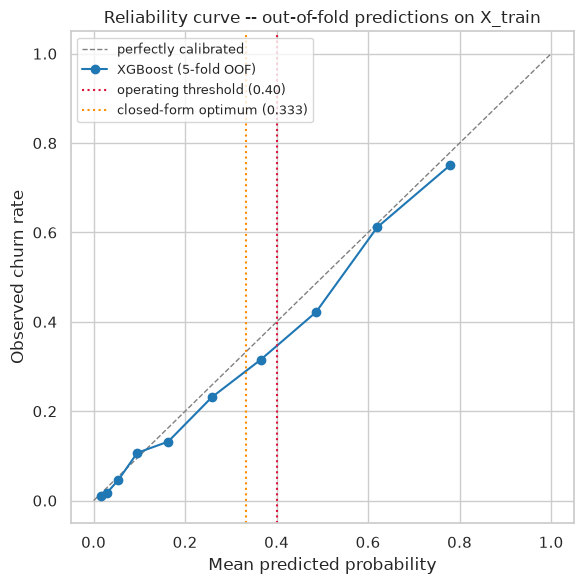

Brier score:                          0.1342
Mean calibration gap, all bins:       +0.0222
Calibration gap in [0.30, 0.50):      +0.0505   (n=964, where the threshold sits)

Closed-form optimum (baseline):       0.3333
Grid-searched threshold (baseline):   0.4000   offset +0.0667
Mean offset across all 15 sweep rows: +0.0464   (15/15 positive)

That mean offset (+0.046) and the calibration gap where the
decision is made (+0.051) agree to within 0.004.
That is the whole explanation: probabilities run hot near the boundary,
so the profit-maximising cutoff moves up to compensate. The single
baseline row is a coarser read -- one argmax on a flat curve.

Note the gap is NOT uniform. Averaged over all bins the model runs only
0.022 hot; it is roughly twice that in the band that matters.

Practical reading: a customer scored 0.45 by this model churns about 39%
of the time, not 45%. Worth stating before anyone treats a raw score as a
probability. Calibrating (Platt/isotonic) would pull the emp

In [27]:
# --- Calibration: WHY the grid-searched threshold sits above the closed form ---
#
# The profit formula has an exact optimum. Targeting a customer is worth it
# when  p * success_rate * clv  >  cost,  so the break-even probability is
# cost / (success_rate * clv) -- with the baseline constants, 20/(0.3*200) =
# 0.333. But the grid above chose 0.40, and every row of the sensitivity
# sweep sits ABOVE its own closed form by a similar margin (mean +0.046,
# 15/15 rows positive). A consistent one-directional gap is not search noise.
#
# The cause is calibration. The closed form assumes the model's output IS a
# probability; the grid does not have to. If the scores run hot, the grid
# compensates by demanding a higher one -- which is exactly what it did, and
# the reason the empirical search earns its keep rather than being replaced
# by the formula.

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(y_train, oof_proba, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label='perfectly calibrated')
ax.plot(prob_pred, prob_true, 'o-', color='#1f77b4', label='XGBoost (5-fold OOF)')
ax.axvline(FINAL_THRESHOLD, color='crimson', linestyle=':', linewidth=1.5,
           label=f'operating threshold ({FINAL_THRESHOLD:.2f})')
ax.axvline(break_even_threshold(clv=clv, cost=cost, success_rate=success_rate), color='darkorange', linestyle=':', linewidth=1.5,
           label=f'closed-form optimum ({break_even_threshold(clv=clv, cost=cost, success_rate=success_rate):.3f})')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed churn rate')
ax.set_title('Reliability curve -- out-of-fold predictions on X_train')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# Quantify it where it actually matters. The gap is NOT uniform: averaged over
# all bins the model runs only ~2 points hot, but in the band the decision is
# made in it runs ~5 points hot -- which is what the threshold offset reflects.
overall_gap = prob_pred.mean() - prob_true.mean()
band = (oof_proba >= 0.30) & (oof_proba < 0.50)
band_gap = oof_proba[band].mean() - y_train[band].mean()
closed_form = break_even_threshold(clv=clv, cost=cost, success_rate=success_rate)

# Mean offset across the whole sensitivity sweep, recomputed here rather than
# quoted, using the same helper the sweep itself used. One row is a single
# argmax on a flat curve and is noisy (the baseline row is +0.067); the mean
# over 15 rows is the stable estimate of the systematic shift.
offsets = []
for _param, _base_val in base.items():
    for _pct in [-0.5, -0.25, 0, 0.25, 0.5]:
        _p = dict(base)
        _p[_param] = _base_val * (1 + _pct)
        _cf = break_even_threshold(clv=_p["clv"], cost=_p["cost"], success_rate=_p["success_rate"])
        _grid, _ = best_threshold_for(_p["clv"], _p["cost"], _p["success_rate"],
                                      oof_proba, y_train)
        offsets.append(_grid - _cf)
mean_offset = float(np.mean(offsets))

print(f"Brier score:                          {brier_score_loss(y_train, oof_proba):.4f}")
print(f"Mean calibration gap, all bins:       {overall_gap:+.4f}")
print(f"Calibration gap in [0.30, 0.50):      {band_gap:+.4f}   (n={band.sum()}, where the threshold sits)")
print()
print(f"Closed-form optimum (baseline):       {closed_form:.4f}")
print(f"Grid-searched threshold (baseline):   {FINAL_THRESHOLD:.4f}   offset {FINAL_THRESHOLD - closed_form:+.4f}")
print(f"Mean offset across all {len(offsets)} sweep rows: {mean_offset:+.4f}   "
      f"({sum(o > 0 for o in offsets)}/{len(offsets)} positive)")
print()
print(f"That mean offset ({mean_offset:+.3f}) and the calibration gap where the")
print(f"decision is made ({band_gap:+.3f}) agree to within {abs(mean_offset - band_gap):.3f}.")
print("That is the whole explanation: probabilities run hot near the boundary,")
print("so the profit-maximising cutoff moves up to compensate. The single")
print("baseline row is a coarser read -- one argmax on a flat curve.")
print()
print("Note the gap is NOT uniform. Averaged over all bins the model runs only")
print(f"{overall_gap:.3f} hot; it is roughly twice that in the band that matters.")
print()
print("Practical reading: a customer scored 0.45 by this model churns about 39%")
print("of the time, not 45%. Worth stating before anyone treats a raw score as a")
print("probability. Calibrating (Platt/isotonic) would pull the empirical")
print("threshold toward the closed form -- it would not change the RANKING, so")
print("ROC-AUC would be unchanged.")


In [28]:
# 5. Compute the same score/profit breakdown on the TEST set, at the single
#    locked-in FINAL_THRESHOLD -- for direct comparison against the OOF
#    table above. This is the first and only time X_test factors into any
#    profit number.
y_pred_test_final = (y_proba >= FINAL_THRESHOLD).astype(int)

precision_test = precision_score(y_test, y_pred_test_final, pos_label=1, zero_division=0)
recall_test = recall_score(y_test, y_pred_test_final, pos_label=1)
f1_test = f1_score(y_test, y_pred_test_final, pos_label=1)
false_positives_test = ((y_pred_test_final == 1) & (y_test == 0)).sum()
false_negatives_test = ((y_pred_test_final == 0) & (y_test == 1)).sum()
total_actual_churners_test = y_test.sum()
true_positives_test = total_actual_churners_test - false_negatives_test

profit_test = campaign_profit(
    true_positives_test, false_positives_test,
    clv=clv, cost=cost, success_rate=success_rate
)

test_result_table = pd.DataFrame([{
    'Dataset': 'X_test (held-out, first touch)',
    'Threshold': FINAL_THRESHOLD,
    'Precision (Confidence)': round(precision_test, 3),
    'Recall (Catch Rate)': round(recall_test, 3),
    'F1-Score': round(f1_test, 3),
    'False Alarms (FP)': false_positives_test,
    'Missed Churners (FN)': false_negatives_test,
    'True Positives (TP)': true_positives_test,
    'Campaign Profit ($)': profit_test
}])

# Pull the matching row from the OOF fine-grid scan for side-by-side comparison
# np.isclose, not ==. Exact equality happens to work today because both
# sides come from the same array AND 0.40 is one of the values np.arange
# lands on exactly. That second part is luck: in 17 of the 19 possible fine
# windows the grid holds values that are not exactly their 2dp form (0.41
# arrives as 0.41000000000000003), this window included. Compare a 0.41
# read back from model_metadata.json against such a grid and == finds
# nothing, with .iloc[0] raising IndexError rather than returning a wrong
# row. The np.round() on the grid above removes the problem at its source;
# this is the belt to that pair of braces.
oof_row = fine_table[np.isclose(fine_table['Threshold'], FINAL_THRESHOLD)].iloc[0]
oof_result_table = pd.DataFrame([{
    'Dataset': 'X_train OOF (used to pick threshold)',
    'Threshold': oof_row['Threshold'],
    'Precision (Confidence)': oof_row['Precision (Confidence)'],
    'Recall (Catch Rate)': oof_row['Recall (Catch Rate)'],
    'F1-Score': oof_row['F1-Score'],
    'False Alarms (FP)': oof_row['False Alarms (FP)'],
    'Missed Churners (FN)': oof_row['Missed Churners (FN)'],
    'True Positives (TP)': oof_row['True Positives (TP)'],
    'Campaign Profit ($)': oof_row['Campaign Profit ($)']
}])

comparison_table = pd.concat([oof_result_table, test_result_table], ignore_index=True)
print("\n=== Train (OOF) vs. Held-Out Test Comparison (same FINAL_THRESHOLD) ===")
print(comparison_table.to_string(index=False))

print("\n--- Final held-out test performance at chosen threshold ---")
print(classification_report(y_test, y_pred_test_final))


=== Train (OOF) vs. Held-Out Test Comparison (same FINAL_THRESHOLD) ===
                             Dataset  Threshold  Precision (Confidence)  Recall (Catch Rate)  F1-Score  False Alarms (FP)  Missed Churners (FN)  True Positives (TP)  Campaign Profit ($)
X_train OOF (used to pick threshold)        0.4                   0.582                0.700     0.636              748.0                 445.0               1040.0              26640.0
      X_test (held-out, first touch)        0.4                   0.589                0.688     0.634              179.0                 116.0                256.0               6660.0

--- Final held-out test performance at chosen threshold ---
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1033
           1       0.59      0.69      0.63       372

    accuracy                           0.79      1405
   macro avg       0.73      0.76      0.74      1405
weighted avg       0.80      0.79   

In [29]:
final_conf_matrix = confusion_matrix(y_test, y_pred_test_final)
final_roc_auc = roc_auc_score(y_test, y_proba)
# Both are threshold-independent ranking metrics -- neither is affected by
# FINAL_THRESHOLD. PR-AUC's baseline is the churn rate rather than 0.5, so it
# is printed next to the score; the ratio is how much better than random the
# ranking actually is for the minority class.
final_pr_auc = average_precision_score(y_test, y_proba)
test_prevalence = y_test.mean()
print(f'chosen threshold: {FINAL_THRESHOLD:.4f}')
print("=== Final Model — Held-Out Test Performance (best_tuned_model @ FINAL_THRESHOLD) ===")
print(f"ROC-AUC: {final_roc_auc:.4f}")
print(f"PR-AUC:  {final_pr_auc:.4f}   (random baseline {test_prevalence:.4f} "
      f"-> {final_pr_auc / test_prevalence:.2f}x better than random)\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_test_final))
print("Confusion Matrix:")
print(final_conf_matrix)

chosen threshold: 0.4000
=== Final Model — Held-Out Test Performance (best_tuned_model @ FINAL_THRESHOLD) ===
ROC-AUC: 0.8441
PR-AUC:  0.6610   (random baseline 0.2648 -> 2.50x better than random)

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1033
           1       0.59      0.69      0.63       372

    accuracy                           0.79      1405
   macro avg       0.73      0.76      0.74      1405
weighted avg       0.80      0.79      0.79      1405

Confusion Matrix:
[[854 179]
 [116 256]]


### Advanced Evaluation Metrics

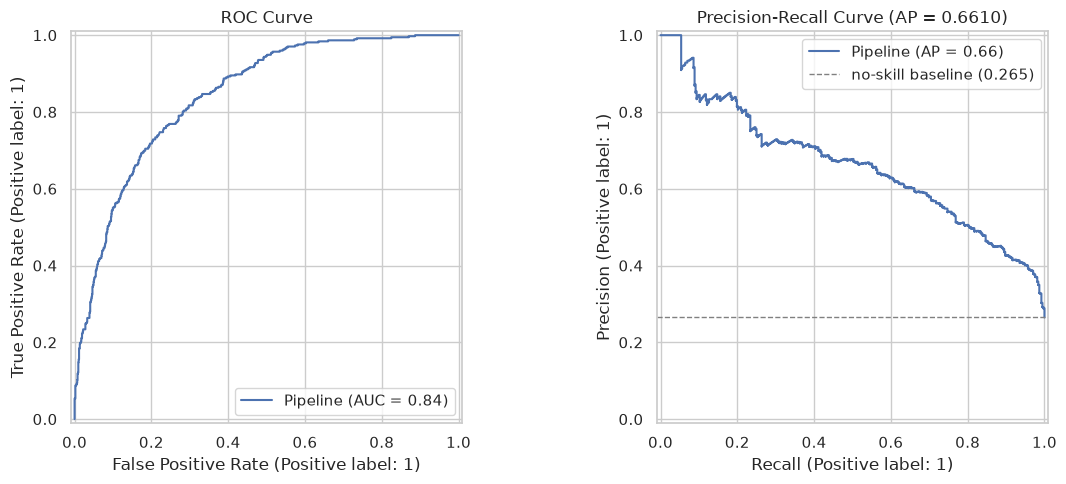

In [30]:

from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
RocCurveDisplay.from_estimator(best_tuned_model, X_test, y_test, ax=ax1)
ax1.set_title("ROC Curve")

# Precision-Recall Curve. The dashed line is the no-skill baseline: a model
# that ranks at random achieves precision equal to the churn rate at every
# recall. ROC's equivalent baseline is the 0.5 diagonal regardless of
# imbalance, which is exactly why the PR view is the more honest one here.
PrecisionRecallDisplay.from_estimator(best_tuned_model, X_test, y_test, ax=ax2)
ax2.axhline(y_test.mean(), color='grey', linestyle='--', linewidth=1,
            label=f'no-skill baseline ({y_test.mean():.3f})')
ax2.legend(loc='upper right')
ax2.set_title(f"Precision-Recall Curve (AP = {average_precision_score(y_test, y_proba):.4f})")

plt.tight_layout()
plt.show()


### Model Comparison

In [31]:
comparison_results = []
# Keep each tuned estimator so the appendix at the end of the notebook can
# ask whether these models make the SAME mistakes. Storing them changes
# nothing about the search or the table below.
tuned_estimators = {}
# Per-fold CV scores at each model's winning parameter set. Kept because the
# significance-test appendix needs them and cv_results_ dies with the search
# object. All three searches run the SAME cv_strategy over the SAME X_tr/y_tr,
# so index k is the same fold for every model -- that is what makes a paired
# test legitimate rather than a comparison of unrelated numbers.
cv_fold_scores = {}
search_spaces = {
    'Logistic Regression': {
        'estimator': LogisticRegression(max_iter=1000, class_weight='balanced'),
        'params': {
            'classifier__C': uniform(0.01, 10),
            # l1_ratio replaces the `penalty` argument, which scikit-learn
            # deprecated in 1.8 and removes in 1.10. 1.0 is pure L1, 0.0 is
            # pure L2 -- the same two options searched before. liblinear
            # supports both and rejects anything in between (that's
            # elasticnet, which needs saga).
            #
            # The search space is unchanged: ParameterSampler sorts its keys,
            # and 'classifier__l1_ratio' sits in the same position between
            # 'classifier__C' and 'classifier__solver' that
            # 'classifier__penalty' did, so the same random_state draws the
            # same 200 (C, penalty) pairs -- verified directly.
            #
            # Results move only in the last decimals: the two code paths
            # are not bit-identical (fitting at a fixed C via penalty='l1'
            # and via l1_ratio=1.0 gives slightly different coefficients),
            # so this model's ROC-AUC goes 0.843897 -> 0.843891. That 6e-6
            # shift is four orders of magnitude below its own 0.019
            # fold-to-fold std. The winning C is not stable run-to-run
            # either way -- the ROC-AUC surface is flat here, so the argmax
            # slides between near-tied draws. Ordering and conclusion in the
            # table below are unaffected.
            'classifier__l1_ratio': [1.0, 0.0],
            'classifier__solver': ['liblinear']
        }
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(class_weight='balanced', random_state=42),
        'params': {
            'classifier__n_estimators': randint(100, 400),
            'classifier__max_depth': randint(3, 20),
            'classifier__min_samples_split': randint(2, 20),
            'classifier__min_samples_leaf': randint(1, 10),
            'classifier__max_features': ['sqrt', 'log2', None]
        }
    }
}
for name, spec in search_spaces.items():
    temp_pipe = Pipeline([
        ('preprocessor', make_preprocessor()),
        ('classifier', spec['estimator'])
    ])

    search = RandomizedSearchCV(
        estimator=temp_pipe,
        param_distributions=spec['params'],
        n_iter=200,                # same budget as the XGBoost search
        scoring='roc_auc',
        cv=cv_strategy,
        random_state=42,
        n_jobs=-1
    )
    print(f"Tuning {name}...")
    search.fit(X_tr, y_tr)   # <-- was X_train, y_train; now matches the data slice XGBoost's search used
    tuned_estimators[name] = search.best_estimator_
    cv_fold_scores[name] = [
        search.cv_results_[f'split{k}_test_score'][search.best_index_]
        for k in range(cv_strategy.get_n_splits())
    ]

    # --- Profit + accuracy, on the SAME basis as XGBoost's own threshold
    # selection above: 5-fold OOF predictions on X_train (never in-sample),
    # scanned for the profit-maximizing threshold using the same clv/cost/
    # success_rate constants and formula already defined earlier. Scoring
    # at a fixed 0.5 instead would be faster but would contradict the whole
    # point of this project -- 0.5 isn't a threshold anyone chose on purpose.
    model_oof_proba = cross_val_predict(
        search.best_estimator_, X_train, y_train,
        cv=cv_strategy, method='predict_proba', n_jobs=-1
    )[:, 1]

    scan_thresholds = np.arange(0.05, 0.95, 0.01)
    best_profit, best_thresh, best_acc = -np.inf, None, None
    for t in scan_thresholds:
        pred = (model_oof_proba >= t).astype(int)
        tp = ((pred == 1) & (y_train == 1)).sum()
        fp = ((pred == 1) & (y_train == 0)).sum()
        profit = campaign_profit(tp, fp, clv=clv, cost=cost, success_rate=success_rate)
        if profit > best_profit:
            best_profit = profit
            best_thresh = t
            best_acc = (pred == y_train).mean()

    comparison_results.append({
        'Model': name,
        'Mean ROC-AUC': search.best_score_,
        'Std Dev': search.cv_results_['std_test_score'][search.best_index_],
        # Computed on model_oof_proba, i.e. the same out-of-fold predictions
        # the threshold and profit columns use -- not on search.best_score_,
        # which is a CV score over X_tr only. Keeping every column on one
        # basis is what makes the rows comparable.
        'PR-AUC (OOF)': average_precision_score(y_train, model_oof_proba),
        'Best Threshold': round(best_thresh, 2),
        'Accuracy @ Threshold': round(best_acc, 4),
        'Profit @ Threshold ($)': best_profit
    })

# XGBoost's ROC-AUC comes from the search you already ran on X_tr/y_tr -- no
# need to redo it. Its profit/accuracy reuse oof_proba and FINAL_THRESHOLD
# from the threshold-selection cell above, rather than recomputing them --
# guarantees this row can't drift from the numbers already reported earlier
# in the notebook.
cv_fold_scores['XGBoost (Tuned)'] = [
    random_search.cv_results_[f'split{k}_test_score'][random_search.best_index_]
    for k in range(cv_strategy.get_n_splits())
]

xgb_pred_at_threshold = (oof_proba >= FINAL_THRESHOLD).astype(int)
xgb_accuracy = (xgb_pred_at_threshold == y_train).mean()
xgb_tp = ((xgb_pred_at_threshold == 1) & (y_train == 1)).sum()
xgb_fp = ((xgb_pred_at_threshold == 1) & (y_train == 0)).sum()
xgb_profit = campaign_profit(xgb_tp, xgb_fp, clv=clv, cost=cost, success_rate=success_rate)

comparison_results.append({
    'Model': 'XGBoost (Tuned)',
    'Mean ROC-AUC': random_search.best_score_,
    'Std Dev': random_search.cv_results_['std_test_score'][random_search.best_index_],
    'PR-AUC (OOF)': average_precision_score(y_train, oof_proba),
    'Best Threshold': round(FINAL_THRESHOLD, 2),
    'Accuracy @ Threshold': round(xgb_accuracy, 4),
    'Profit @ Threshold ($)': xgb_profit
})

df_compare = pd.DataFrame(comparison_results).sort_values(by='Mean ROC-AUC', ascending=False)
print("--- Model Comparison (all models tuned on the same X_tr/y_tr slice; profit/accuracy on 5-fold OOF over X_train) ---")
print(df_compare)
# Selection is still driven by ROC-AUC (scoring='roc_auc' above); PR-AUC is
# reported, not optimised. Changing the search metric would change which
# model ships, which is a different decision from measuring one more thing.
print(f"\nPR-AUC random baseline (churn rate in X_train): {y_train.mean():.4f}")

Tuning Logistic Regression...
Tuning Random Forest...
--- Model Comparison (all models tuned on the same X_tr/y_tr slice; profit/accuracy on 5-fold OOF over X_train) ---
                 Model  Mean ROC-AUC   Std Dev  PR-AUC (OOF)  Best Threshold  \
2      XGBoost (Tuned)      0.845812  0.019575      0.660301            0.40   
1        Random Forest      0.844126  0.016803      0.653229            0.58   
0  Logistic Regression      0.843900  0.018874      0.654777            0.58   

   Accuracy @ Threshold  Profit @ Threshold ($)  
2                0.7876                 26640.0  
1                0.7810                 27000.0  
0                0.7758                 26200.0  

PR-AUC random baseline (churn rate in X_train): 0.2644


"""***i should decide whether stacking might give a small increase (0.002-0.008)%5%) or not after comparing the individual probabilities not the roc auc and stddev***"""

decided, not it doesnt


### SHAP Dependence Analysis

/home/yaponsk/div_academy_aie_tasks/ml_projects_4/.venv/lib/python3.12/site-packages/shap/plots/colors/_colors.py:47: PendingDeprecationWarning: The set_bad function will be deprecated in a future version. Use cmap.with_extremes(bad=...) or Colormap(bad=...) instead.
  red_blue.set_bad(gray_rgb.tolist(), 1.0)
/home/yaponsk/div_academy_aie_tasks/ml_projects_4/.venv/lib/python3.12/site-packages/shap/plots/colors/_colors.py:48: PendingDeprecationWarning: The set_over function will be deprecated in a future version. Use cmap.with_extremes(over=...) or Colormap(over=...) instead.
  red_blue.set_over(gray_rgb.tolist(), 1.0)
/home/yaponsk/div_academy_aie_tasks/ml_projects_4/.venv/lib/python3.12/site-packages/shap/plots/colors/_colors.py:49: PendingDeprecationWarning: The set_under function will be deprecated in a future version. Use cmap.with_extremes(under=...) or Colormap(under=...) instead.
  red_blue.set_under(gray_rgb.tolist(), 1.0)  # "under" is incorrectly used instead of "bad" in the 

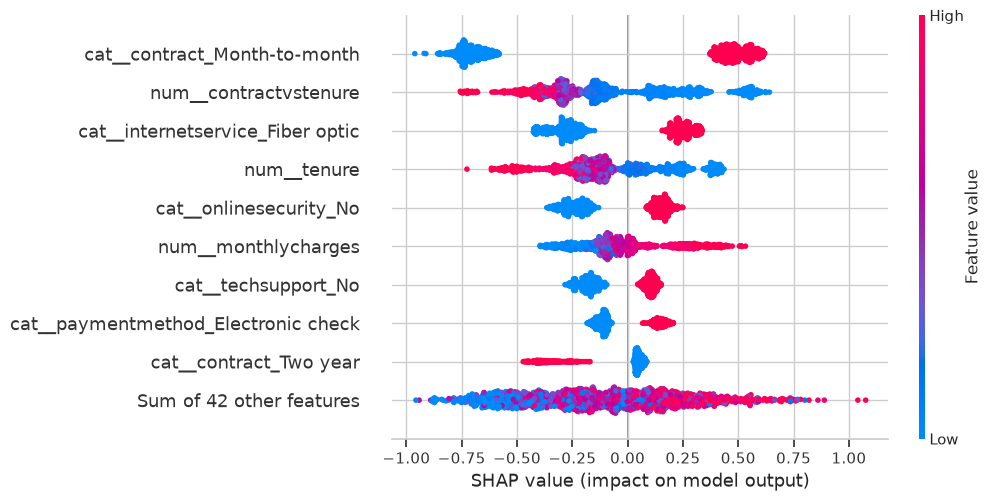

In [32]:
#    1. Transform the raw X_test using the preprocessor from your tuned model
import shap


X_test_transformed = best_tuned_model.named_steps['preprocessor'].transform(X_test)

# 2. Extract feature names from the tuned preprocessor
feature_names = best_tuned_model.named_steps['preprocessor'].get_feature_names_out()

# 3. Create the SHAP explainer targeting the tuned XGBoost classifier
explainer = shap.TreeExplainer(best_tuned_model.named_steps['classifier'])

# 4. Calculate SHAP values
shappies = explainer(X_test_transformed)
shappies.feature_names = feature_names

# 5. Generate the global beeswarm plot
shap.plots.beeswarm(shappies)

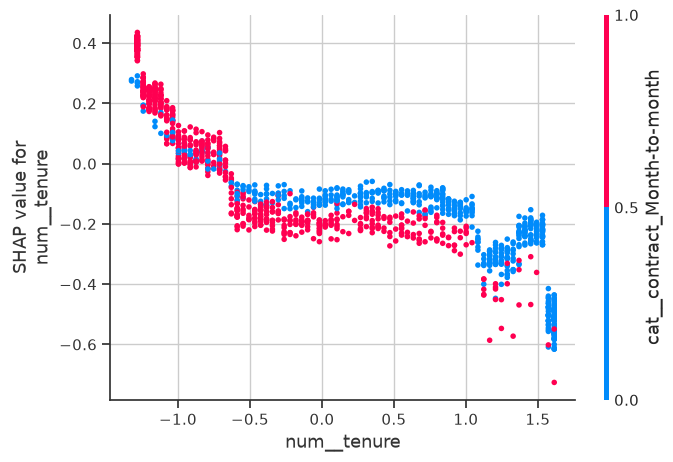

In [33]:
# SHAP Dependence Plot for the most important feature (e.g., tenure)
tenure_feature = "num__tenure"
assert tenure_feature in feature_names, f"{tenure_feature} not found in feature_names"

shap.dependence_plot(
    tenure_feature,
    shappies.values,
    X_test_transformed,
    feature_names=feature_names
)

In [34]:
import joblib
import json
import subprocess
import sklearn
import xgboost
from datetime import datetime, timezone

from config import DUMMY_CUSTOMER


def get_git_commit():
    """Best-effort git commit hash for reproducibility. Returns None if this
    isn't a git repo (e.g. a fresh clone before `git init`, or a zipped
    download) rather than failing the whole cell."""
    try:
        return subprocess.check_output(
            ['git', 'rev-parse', 'HEAD'], stderr=subprocess.DEVNULL
        ).decode('utf-8').strip()
    except (subprocess.CalledProcessError, FileNotFoundError):
        return None


joblib.dump(best_tuned_model, 'xgboost_churn_pipeline.pkl')

with open('model_metadata.json', 'w') as f:
    json.dump({
        'threshold': float(FINAL_THRESHOLD),
        'model': 'XGBoost (Tuned)',
        'cv_roc_auc_mean': float(cv_roc_auc.mean()),
        'cv_roc_auc_std': float(cv_roc_auc.std()),
        # PR-AUC recorded next to ROC-AUC because with ~26% churn it is the
        # more sensitive read on minority-class ranking. Nothing loads these
        # at runtime -- they are provenance for the README's Results table.
        'cv_pr_auc_mean': float(cv_pr_auc.mean()),
        'cv_pr_auc_std': float(cv_pr_auc.std()),
        'churn_rate_train': float(y_train.mean()),
        'trained_at': datetime.now(timezone.utc).isoformat(),
        'git_commit': get_git_commit(),
        'feature_schema_version': '1.0',
        'hash': df_hash,
        # Exact library versions that produced this pickle. joblib/pickle
        # ties a Pipeline's serialized state to the exact scikit-learn/
        # XGBoost version that created it -- neither project guarantees
        # pickle compatibility across releases. config.validate_environment_
        # versions() compares this against the runtime environment at API/
        # batch-script startup and WARNS on a mismatch -- it does not block
        # startup; a hard gate on this belongs in CI, not the live service.
        'library_versions': {
            'scikit-learn': sklearn.__version__,
            'xgboost': xgboost.__version__,
            'numpy': np.__version__,
            'pandas': pd.__version__,
        },
        # Raw, pre-feature-engineering columns the pipeline's preprocessor
        # expects on the input side -- lets a caller (or a future you)
        # confirm at a glance whether this model matches the current
        # feature_engineering_telco.py contract.
        'feature_columns': X_train.columns.tolist(),
        # Probability this exact pickle assigns to config.DUMMY_CUSTOMER.
        # Recorded here so tests/test_artifact.py can pin the artifact's
        # behaviour without the expected value being hand-maintained: a
        # retrain rewrites both the pickle and this number together, so the
        # canary can only fail when the pickle and the environment disagree
        # -- a corrupted artifact, or a library version that unpickles
        # cleanly but predicts differently. That silent-behaviour-change
        # case is exactly what verify_version_check.sh says it cannot check.
        'dummy_customer_score': float(
            best_tuned_model.predict_proba(
                engineer_features(pd.DataFrame([DUMMY_CUSTOMER]))
            )[:, 1][0]
        ),
    }, f, indent=2)

X_test_raw.sample(50, random_state=42).to_csv('simulated_new_customers.csv', index=False)

In [35]:
assert set(X_train.columns) == set(engineer_features(X_test.iloc[:1]).columns), \
    "X_train columns and a fresh engineer_features() call disagree — investigate before saving."

In [36]:
import json
with open('model_metadata.json') as f:
    meta = json.load(f)
print(f"threshold: {meta['threshold']:.3f}")
print(f"feature columns: {meta['feature_columns']}")

threshold: 0.400
feature columns: ['gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'total_services', 'is_auto_pay', 'family_tie', 'contractvstenure', 'average_monthly_charges', 'charge_change_ratio']


## Appendix — reading the scores as probabilities

Everything above ships as-is: the pickled pipeline, `model_metadata.json`
and the 0.40 operating threshold are **unchanged by this section**.

The calibration check earlier showed the model's scores run hot near the
decision boundary, which is why the searched threshold (0.40) sits above
the closed-form optimum (0.333). This appendix does two things with that:
it shows what the reliability curve looks like once the scores *are*
calibrated, and it prints a translation table for converting a raw score
into an actual risk estimate.

The calibration is fitted for display only and is deliberately **not**
saved into the artifact. Platt scaling is monotonic, so it cannot reorder
customers and cannot improve which ones get targeted — the profit is the
same either way. What it buys is a number that means what it says, which
matters when quoting a score to someone rather than acting on it.

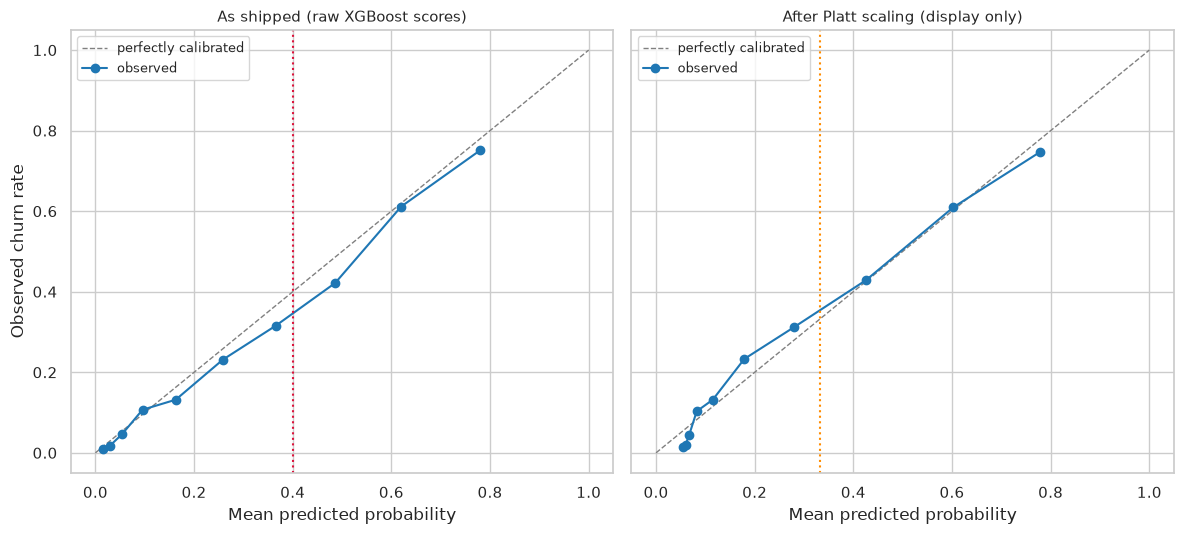

What the shipped model's score really means
(read this to convert an API response into a risk estimate)

  raw score  ->  actual risk
     0.10     ->    0.08
     0.20     ->    0.14
     0.30     ->    0.21
     0.40     ->    0.32   <- operating threshold
     0.45     ->    0.38
     0.50     ->    0.44
     0.60     ->    0.58
     0.70     ->    0.70
     0.80     ->    0.80
     0.90     ->    0.88

Profit-optimal threshold on calibrated scores: 0.32
Closed-form optimum cost/(success_rate*clv):   0.333
  -> calibrating moves the empirical optimum onto the formula, which is
     the confirmation that the gap really was miscalibration.

Profit, raw scores @ 0.40:        $26,640
Profit, calibrated  @ 0.32:        $26,680
Same targeting decision for 99.8% of customers.

Which is why the shipped model is left uncalibrated: Platt scaling is
monotonic, so it cannot reorder customers and cannot pick a better set
to target. It buys a readable probability, not a better campaign. The
ranki

In [37]:
# --- Display-only: what the scores would look like calibrated ---
#
# NOTHING BELOW IS SAVED OR SHIPPED. The pickled pipeline, the metadata and
# the 0.40 operating threshold are all unchanged. This cell exists to answer
# one question -- "what does a score of 0.45 actually mean?" -- and to show
# that the earlier calibration diagnosis holds up when acted on.
#
# Platt scaling is a logistic regression fitted on the model's own scores.
# It is fitted here on the out-of-fold predictions (never in-sample), and
# its own reliability curve is built from a further 5-fold split of those,
# so the "after" line below is honest rather than self-graded.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict as _cvp
from sklearn.calibration import calibration_curve

_scores = oof_proba.reshape(-1, 1)
_platt = LogisticRegression().fit(_scores, y_train)
calibrated_oof = _cvp(LogisticRegression(), _scores, y_train,
                      cv=cv_strategy, method='predict_proba')[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
for ax, (probs, title) in zip(axes, [(oof_proba, 'As shipped (raw XGBoost scores)'),
                                     (calibrated_oof, 'After Platt scaling (display only)')]):
    pt, pp = calibration_curve(y_train, probs, n_bins=10, strategy='quantile')
    ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label='perfectly calibrated')
    ax.plot(pp, pt, 'o-', color='#1f77b4', label='observed')
    ax.set_xlabel('Mean predicted probability')
    ax.set_title(title, fontsize=11)
    ax.legend(loc='upper left', fontsize=9)
axes[0].set_ylabel('Observed churn rate')
axes[0].axvline(FINAL_THRESHOLD, color='crimson', linestyle=':', linewidth=1.5)
axes[1].axvline(break_even_threshold(clv=clv, cost=cost, success_rate=success_rate), color='darkorange', linestyle=':', linewidth=1.5)
plt.tight_layout()
plt.show()

# Translation table: what a shipped score actually means.
print("What the shipped model's score really means")
print("(read this to convert an API response into a risk estimate)\n")
print("  raw score  ->  actual risk")
for raw in [0.1, 0.2, 0.3, 0.4, 0.45, 0.5, 0.6, 0.7, 0.8, 0.9]:
    real = _platt.predict_proba([[raw]])[0, 1]
    flag = "   <- operating threshold" if abs(raw - FINAL_THRESHOLD) < 1e-9 else ""
    print(f"     {raw:.2f}     ->    {real:.2f}{flag}")

_cf = break_even_threshold(clv=clv, cost=cost, success_rate=success_rate)
_best_t, _best_p = best_threshold_for(clv, cost, success_rate, calibrated_oof, y_train)
_raw_t, _raw_p = best_threshold_for(clv, cost, success_rate, oof_proba, y_train)
_agree = ((oof_proba >= _raw_t) == (calibrated_oof >= _best_t)).mean()

print(f"\nProfit-optimal threshold on calibrated scores: {_best_t:.2f}")
print(f"Closed-form optimum cost/(success_rate*clv):   {_cf:.3f}")
print(f"  -> calibrating moves the empirical optimum onto the formula, which is")
print(f"     the confirmation that the gap really was miscalibration.")
print(f"\nProfit, raw scores @ {_raw_t:.2f}:        ${_raw_p:,.0f}")
print(f"Profit, calibrated  @ {_best_t:.2f}:        ${_best_p:,.0f}")
print(f"Same targeting decision for {_agree:.1%} of customers.")
print("\nWhich is why the shipped model is left uncalibrated: Platt scaling is")
print("monotonic, so it cannot reorder customers and cannot pick a better set")
print("to target. It buys a readable probability, not a better campaign. The")
print("ranking-plus-threshold split already delivers the decision correctly;")
print("this table is what to use when someone needs the number to mean something.")


## Appendix — are the three models making the same mistakes?

The comparison table shows XGBoost, Random Forest and Logistic Regression
within 0.002 ROC-AUC of each other, and I read that as an information
ceiling in the data. But three similar scores are only *circumstantial*
evidence for that — models can reach the same accuracy by being right and
wrong about completely different customers, and if they did, pooling them
would beat any of them individually.

So rather than stop at the scores, this section checks the errors
themselves: which specific customers each model gets wrong, how much those
sets overlap, and whether averaging the three actually buys anything.
That is the difference between inferring a ceiling and demonstrating one.

Like the calibration appendix above, nothing here is saved — it is a
diagnostic run after the artifact has already been written.

Error correlation -- corr(y - p) between models.
This, not score correlation, is what decides whether combining helps.

                          XGBoost (Tune  Logistic Regr  Random Forest
  XGBoost (Tuned)                 1.000          0.964          0.977
  Logistic Regression             0.964          1.000          0.980
  Random Forest                   0.977          0.980          1.000

Who is wrong about whom (each model at its own threshold):
  XGBoost (Tuned)        1193 errors  (21.2%)
  Logistic Regression    1258 errors  (22.4%)
  Random Forest          1230 errors  (21.9%)
  XGBoost (Tuned)       & Logistic Regression   both wrong 1023   Jaccard 0.72
  XGBoost (Tuned)       & Random Forest         both wrong 1063   Jaccard 0.78
  Logistic Regression   & Random Forest         both wrong 1064   Jaccard 0.75

  wrong for EVERY model: 966     wrong for at least one: 1497
  -> 64.5% of all errors are shared by all three models

Would pooling them help?
  XGBoost (Tuned)   

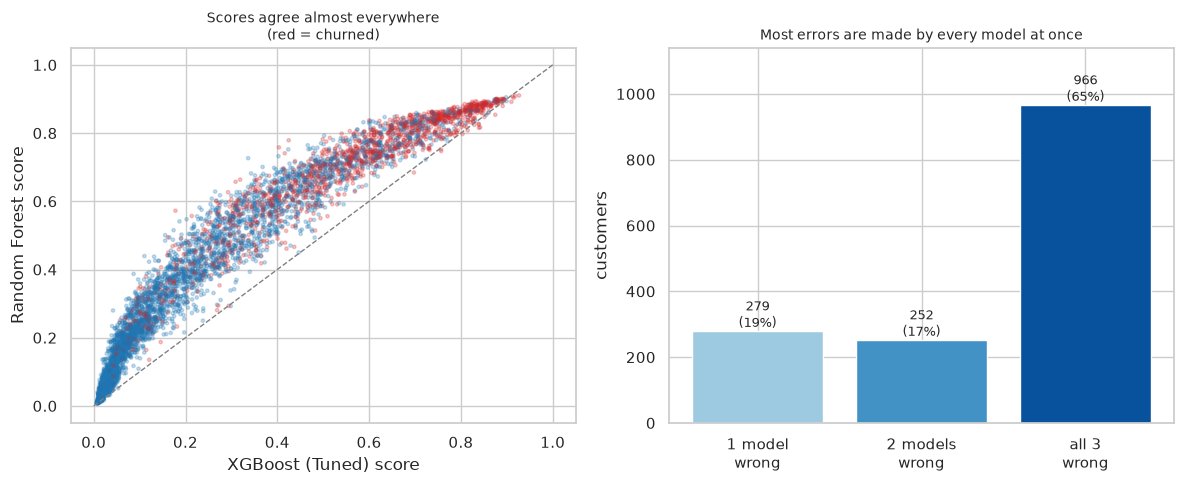


Reading: the models are wrong about the same customers, so there is no
independent signal to pool. That is direct evidence for an
information ceiling, rather than inferring one from three similar scores.
Stacking or blending would be adding machinery to average three views
of the same thing. The remaining error looks like it lives outside the
dataset (competitor offers, individual service interactions), not in a
model family nobody has tried yet.


In [38]:
# --- Do the three models make the SAME mistakes? ---
#
# The comparison table shows XGBoost, Random Forest and Logistic Regression
# landing within 0.002 ROC-AUC of each other, which suggests the data has an
# information ceiling. That is an inference from three similar numbers. This
# cell tests it directly.
#
# The logic: combining models only pays when they fail on DIFFERENT rows. Two
# models at the same accuracy that are wrong about the same customers are
# seeing the same signal and there is nothing to pool. Two that are wrong
# about different customers each hold something the other lacks. So rather
# than compare scores, compare errors.
#
# Nothing here is saved -- this is a diagnostic, like the calibration
# appendix above.

import itertools
from sklearn.metrics import roc_auc_score, average_precision_score

model_oof = {'XGBoost (Tuned)': oof_proba}
for _name, _est in tuned_estimators.items():
    model_oof[_name] = cross_val_predict(_est, X_train, y_train,
                                         cv=cv_strategy, method='predict_proba',
                                         n_jobs=-1)[:, 1]
_names = list(model_oof)

# Each model judged at its OWN profit-optimal threshold -- comparing them at a
# shared cutoff would manufacture disagreement that the deployed system would
# never see, since each model ships with its own threshold.
_thresholds = {n: best_threshold_for(clv, cost, success_rate, p, y_train)[0]
               for n, p in model_oof.items()}
errors = {n: (model_oof[n] >= _thresholds[n]).astype(int) != y_train.to_numpy()
          for n in _names}

print("Error correlation -- corr(y - p) between models.")
print("This, not score correlation, is what decides whether combining helps.\n")
print("                        " + "".join(f"{n[:13]:>15}" for n in _names))
for a in _names:
    row = "".join(f"{np.corrcoef(y_train - model_oof[a], y_train - model_oof[b])[0, 1]:>15.3f}"
                  for b in _names)
    print(f"  {a:22}{row}")

print("\nWho is wrong about whom (each model at its own threshold):")
for n in _names:
    print(f"  {n:22} {errors[n].sum():4d} errors  ({errors[n].mean():.1%})")
for a, b in itertools.combinations(_names, 2):
    _i = (errors[a] & errors[b]).sum(); _u = (errors[a] | errors[b]).sum()
    print(f"  {a:21} & {b:21} both wrong {_i:4d}   Jaccard {_i / _u:.2f}")

_all = np.logical_and.reduce([errors[n] for n in _names])
_any = np.logical_or.reduce([errors[n] for n in _names])
print(f"\n  wrong for EVERY model: {_all.sum()}     wrong for at least one: {_any.sum()}")
print(f"  -> {_all.sum() / _any.sum():.1%} of all errors are shared by all three models")

# If the errors really were independent, averaging would help. Test it.
_avg = np.mean(list(model_oof.values()), axis=0)
_avg_thr, _avg_profit = best_threshold_for(clv, cost, success_rate, _avg, y_train)
print(f"\nWould pooling them help?")
for n in _names:
    _t, _p = best_threshold_for(clv, cost, success_rate, model_oof[n], y_train)
    print(f"  {n:22} OOF AUC {roc_auc_score(y_train, model_oof[n]):.4f}   "
          f"PR-AUC {average_precision_score(y_train, model_oof[n]):.4f}   "
          f"best thr {_t:.2f}   profit ${_p:,.0f}")
print(f"  {'average of all three':22} OOF AUC {roc_auc_score(y_train, _avg):.4f}   "
      f"PR-AUC {average_precision_score(y_train, _avg):.4f}   "
      f"best thr {_avg_thr:.2f}   profit ${_avg_profit:,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(model_oof[_names[0]], model_oof[_names[-1]], s=6, alpha=0.25,
                c=np.where(y_train == 1, '#d62728', '#1f77b4'))
axes[0].plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
axes[0].set_xlabel(f'{_names[0]} score'); axes[0].set_ylabel(f'{_names[-1]} score')
axes[0].set_title('Scores agree almost everywhere\n(red = churned)', fontsize=10)

_counts = np.sum([errors[n].astype(int) for n in _names], axis=0)
_bars = [(_counts == k).sum() for k in (1, 2, 3)]
axes[1].bar(['1 model\nwrong', '2 models\nwrong', 'all 3\nwrong'], _bars,
            color=['#9ecae1', '#4292c6', '#08519c'])
for _i, _v in enumerate(_bars):
    axes[1].text(_i, _v, f'{_v}\n({_v / _any.sum():.0%})', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('customers'); axes[1].set_ylim(0, max(_bars) * 1.18)
axes[1].set_title('Most errors are made by every model at once', fontsize=10)
plt.tight_layout(); plt.show()

print("\nReading: the models are wrong about the same customers, so there is no")
print("independent signal to pool. That is direct evidence for an")
print("information ceiling, rather than inferring one from three similar scores.")
print("Stacking or blending would be adding machinery to average three views")
print("of the same thing. The remaining error looks like it lives outside the")
print("dataset (competitor offers, individual service interactions), not in a")
print("model family nobody has tried yet.")


stacking is basically useless here, proven by comparing individual results


## Appendix — how precise is 0.40, and is it optimistic?

Two loose ends from the threshold work above, which turn out to be the
same loose end.

**How precise?** `FINAL_THRESHOLD` is the argmax of a profit curve over
~90 candidates. Near an optimum a curve is flat by definition, so an
argmax picks the peak of the noise as much as the peak of the signal. The
sensitivity sweep measured uncertainty in the business *assumptions* and
did it well; uncertainty in the *estimate itself* was never measured.

**Is it optimistic?** The threshold comes from out-of-fold predictions
over `X_train`, but the hyperparameters were chosen on `X_tr`, which is
80% of those same rows. Refitting per fold removes parameter leakage, not
selection leakage — so the scores may be slightly rosy on most rows, and
the threshold tuned to a rosy picture. `X_val` is the clean control: the
search never touched it.

The second question can't be answered without the first. "Is this
threshold shifted?" is meaningless until you know how much it wobbles on
its own. Nothing here is saved; the shipped threshold is unchanged.

How precise is the operating threshold?
  shipped value (argmax over all of X_train OOF): 0.40
  per-fold argmax:  0.404 +/- 0.036   (folds: 0.40, 0.38, 0.45, 0.43, 0.36)
  bootstrap (500):  0.400 +/- 0.047   95% interval [0.29, 0.46]

  -> report it as 0.40 +/- 0.05, not 0.40
  Every threshold in [0.35, 0.46] is within 1% of peak profit,
  so the whole band is operationally the same decision:
     0.35 -> $26,380  (-260 vs peak)
     0.38 -> $26,600  (-40 vs peak)
     0.40 -> $26,640  (+0 vs peak)
     0.43 -> $26,600  (-40 vs peak)
     0.46 -> $26,540  (-100 vs peak)

Is that threshold optimistic? (selection leakage)
  X_tr rows,  hyperparameters DID see them  (n=4492): 0.38  +/- 0.051
  X_val rows, hyperparameters NEVER saw them (n=1124): 0.43  +/- 0.077
  difference (val - tr): +0.029   95% CI [-0.19, +0.18]
  -> the interval INCLUDES zero: leakage is not detectable above the estimator noise


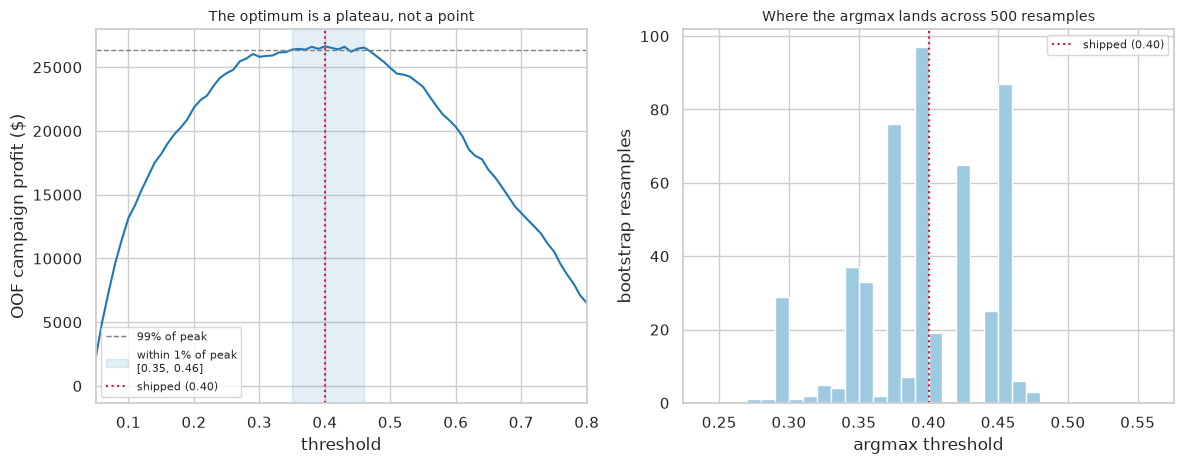


Reading: 0.40 is the centre of a plateau 0.11 wide, and its own resampling spread is +/- 0.047.
Selection leakage shifts it by +0.029, about 61% of that spread, with a
confidence interval straddling zero -- real in mechanism, unmeasurable in
size here. Nested CV would buy precision the profit curve cannot use: the
entire plateau is worth $260 out of $26,640. The honest way to report this
threshold is as a band, not a point.


In [39]:
# --- How precise is the threshold, and is it optimistic? ---
#
# Two questions that turn out to be one.
#
# PRECISION. FINAL_THRESHOLD is the argmax of a profit curve over ~90
# candidates, and near an optimum a curve is flat by definition -- so the
# argmax picks the peak of the noise as much as the peak of the signal. The
# sweep above measures uncertainty in the business assumptions; this measures
# uncertainty in the estimate itself.
#
# BIAS. The threshold comes from out-of-fold predictions over X_train, but the
# hyperparameters were selected on X_tr, 80% of those same rows. Refitting per
# fold removes parameter leakage, not selection leakage, so the scores may be
# mildly optimistic and the threshold tuned to a rosy picture. X_val is the
# clean control: the search never touched it.
#
# The second question needs the first: "is this shifted?" means nothing until
# you know how much it wobbles on its own.
#
# Nothing here is saved. The shipped threshold stays FINAL_THRESHOLD.

_ts = np.arange(0.05, 0.96, 0.01)

def _profit_curve(proba, y_true):
    return profit_curve(y_true, proba, _ts, clv=clv, cost=cost,
                        success_rate=success_rate)

def _argmax_threshold(proba, y_true):
    return best_threshold(y_true, proba, _ts, clv=clv, cost=cost,
                          success_rate=success_rate)[0]

def _bootstrap(proba, y_true, n=500, seed=0):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    draws = [_argmax_threshold(proba[i], y_true[i])
             for i in (rng.integers(0, len(proba), len(proba)) for _ in range(n))]
    return np.array(draws)

_y = y_train.to_numpy()
_curve = _profit_curve(oof_proba, _y)
_peak = _curve.max()

# --- Item 6: two independent reads on the spread ---
_fold_ts = [_argmax_threshold(oof_proba[te], _y[te])
            for _, te in cv_strategy.split(X_train, y_train)]
_boot = _bootstrap(oof_proba, _y)
_flat = _ts[_curve >= 0.99 * _peak]

print("How precise is the operating threshold?")
print(f"  shipped value (argmax over all of X_train OOF): {FINAL_THRESHOLD:.2f}")
print(f"  per-fold argmax:  {np.mean(_fold_ts):.3f} +/- {np.std(_fold_ts, ddof=1):.3f}"
      f"   (folds: {', '.join(f'{t:.2f}' for t in _fold_ts)})")
print(f"  bootstrap (500):  {_boot.mean():.3f} +/- {_boot.std(ddof=1):.3f}"
      f"   95% interval [{np.percentile(_boot, 2.5):.2f}, {np.percentile(_boot, 97.5):.2f}]")
print(f"\n  -> report it as {FINAL_THRESHOLD:.2f} +/- {_boot.std(ddof=1):.2f}, not {FINAL_THRESHOLD:.2f}")
print(f"  Every threshold in [{_flat.min():.2f}, {_flat.max():.2f}] is within 1% of peak profit,")
print(f"  so the whole band is operationally the same decision:")
for _t in (_flat.min(), 0.38, FINAL_THRESHOLD, 0.43, _flat.max()):
    _p = _curve[int(round((_t - 0.05) / 0.01))]
    print(f"     {_t:.2f} -> ${_p:,.0f}  ({_p - _peak:+,.0f} vs peak)")

# --- Bias: rows the hyperparameter search saw vs rows it never did ---
_val_pos = X_train.index.get_indexer(X_val.index)
_tr_pos = X_train.index.get_indexer(X_tr.index)
_b_tr = _bootstrap(oof_proba[_tr_pos], _y[_tr_pos], seed=1)
_b_val = _bootstrap(oof_proba[_val_pos], _y[_val_pos], seed=2)
_diff = _b_val - _b_tr

print("\nIs that threshold optimistic? (selection leakage)")
print(f"  X_tr rows,  hyperparameters DID see them  (n={len(_tr_pos)}): "
      f"{_argmax_threshold(oof_proba[_tr_pos], _y[_tr_pos]):.2f}"
      f"  +/- {_b_tr.std(ddof=1):.3f}")
print(f"  X_val rows, hyperparameters NEVER saw them (n={len(_val_pos)}): "
      f"{_argmax_threshold(oof_proba[_val_pos], _y[_val_pos]):.2f}"
      f"  +/- {_b_val.std(ddof=1):.3f}")
print(f"  difference (val - tr): {_diff.mean():+.3f}   "
      f"95% CI [{np.percentile(_diff, 2.5):+.2f}, {np.percentile(_diff, 97.5):+.2f}]")
_excl = np.percentile(_diff, 2.5) > 0 or np.percentile(_diff, 97.5) < 0
print(f"  -> the interval {'excludes' if _excl else 'INCLUDES'} zero: leakage is "
      f"{'detectable' if _excl else 'not detectable above the estimator noise'}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].plot(_ts, _curve, color='#1f77b4')
axes[0].axhline(0.99 * _peak, color='gray', linestyle='--', linewidth=1, label='99% of peak')
axes[0].axvspan(_flat.min(), _flat.max(), color='#1f77b4', alpha=0.12,
                label=f'within 1% of peak\n[{_flat.min():.2f}, {_flat.max():.2f}]')
axes[0].axvline(FINAL_THRESHOLD, color='crimson', linestyle=':', linewidth=1.5,
                label=f'shipped ({FINAL_THRESHOLD:.2f})')
axes[0].set_xlabel('threshold'); axes[0].set_ylabel('OOF campaign profit ($)')
axes[0].set_title('The optimum is a plateau, not a point', fontsize=10)
axes[0].legend(fontsize=8); axes[0].set_xlim(0.05, 0.8)

axes[1].hist(_boot, bins=np.arange(0.24, 0.56, 0.01), color='#9ecae1', edgecolor='white')
axes[1].axvline(FINAL_THRESHOLD, color='crimson', linestyle=':', linewidth=1.5,
                label=f'shipped ({FINAL_THRESHOLD:.2f})')
axes[1].set_xlabel('argmax threshold'); axes[1].set_ylabel('bootstrap resamples')
axes[1].set_title('Where the argmax lands across 500 resamples', fontsize=10)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"\nReading: {FINAL_THRESHOLD:.2f} is the centre of a plateau "
      f"{_flat.max() - _flat.min():.2f} wide, and its own resampling spread is "
      f"+/- {_boot.std(ddof=1):.3f}.")
print(f"Selection leakage shifts it by {_diff.mean():+.3f}, about "
      f"{abs(_diff.mean()) / _boot.std(ddof=1):.0%} of that spread, with a")
print("confidence interval straddling zero -- real in mechanism, unmeasurable in")
print("size here. Nested CV would buy precision the profit curve cannot use: the")
print(f"entire plateau is worth ${_peak - _curve[_curve >= 0.99 * _peak].min():,.0f} "
      f"out of ${_peak:,.0f}. The honest way to report this")
print("threshold is as a band, not a point.")


## Appendix — is the model gap actually significant?

The comparison table shows three models inside ~0.002 ROC-AUC of each other and
the write-up calls that "probably noise". This tests it instead of asserting it.

Paired Wilcoxon signed-rank on per-fold CV scores. The pairing is legitimate:
all three searches ran the same `cv_strategy` over the same `X_tr`/`y_tr`, and
`StratifiedKFold(shuffle=True, random_state=42)` is deterministic, so fold *k*
is the identical train/test split for every model. Saves nothing.


In [ ]:
from scipy.stats import wilcoxon
from sklearn.model_selection import RepeatedStratifiedKFold
from itertools import combinations

_models = ['XGBoost (Tuned)', 'Random Forest', 'Logistic Regression']

# Pairing check, not an assumption: the same fold indices must come back on
# every call, or the paired test is comparing unrelated numbers.
_a = [(tuple(tr), tuple(te)) for tr, te in cv_strategy.split(X_tr, y_tr)]
_b = [(tuple(tr), tuple(te)) for tr, te in cv_strategy.split(X_tr, y_tr)]
assert _a == _b, "cv_strategy is not deterministic -- the pairing is invalid"
print(f"Folds are identical across calls, so scores are paired by fold index.")
print(f"n = {cv_strategy.get_n_splits()} folds per model\n")

print("=" * 68)
print("Paired Wilcoxon on the 5 CV folds (ROC-AUC)")
print("=" * 68)
for _x, _y in combinations(_models, 2):
    _d = np.array(cv_fold_scores[_x]) - np.array(cv_fold_scores[_y])
    _p = wilcoxon(cv_fold_scores[_x], cv_fold_scores[_y]).pvalue
    print(f"  {_x:20} vs {_y:20}  p = {_p:.4f}   mean diff {_d.mean():+.6f}")

# The floor matters more than any of those p-values. With 5 pairs there are
# 2**5 = 32 equally likely sign patterns under the null, so the smallest
# two-sided p the test can return is 2/32 = 0.0625. No 5-fold result can ever
# clear 0.05. "Not significant" here is a statement about the sample size,
# not about the models.
_floor = wilcoxon([1, 1, 1, 1, 1], [0, 0, 0, 0, 0]).pvalue
print(f"\n  Smallest p attainable with 5 pairs: {_floor:.4f}"
      f" -- so p < 0.05 is unreachable regardless of the data.")

print("\n" + "=" * 68)
print("Powered companion: 5x5 repeated CV = 25 paired folds")
print("=" * 68)
# Same tuned estimators, more folds. Repeats reuse overlapping training data,
# so these p-values are optimistic (Nadeau & Bengio) -- but a test that CAN
# reject and does not is informative, where one that cannot reject is not.
_rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
_est = dict(tuned_estimators)
_est['XGBoost (Tuned)'] = best_tuned_model
_rep = {m: cross_val_score(_est[m], X_tr, y_tr, cv=_rcv, scoring='roc_auc', n_jobs=-1)
        for m in _models}
for m in _models:
    print(f"  {m:20} mean {_rep[m].mean():.6f}  +/- {_rep[m].std():.6f}")
print()
_verdict = []
for _x, _y in combinations(_models, 2):
    _d = _rep[_x] - _rep[_y]
    _p = wilcoxon(_rep[_x], _rep[_y]).pvalue
    _verdict.append(_p < 0.05)
    _sig = "SIGNIFICANT" if _p < 0.05 else "not significant"
    print(f"  {_x:20} vs {_y:20}  p = {_p:.4f}   mean diff {_d.mean():+.6f}   {_sig}")

print("\nReading: with 25 paired folds the test has real power. "
      f"{sum(_verdict)} of 3 pairs separate at alpha=0.05.")
